In [ ]:
"""
Python Version: 3.13.1

"""
import pandas as pd
import numpy as np
#Pytorch 
import torch
from torch import nn
from torch.utils.data import DataLoader,Subset,TensorDataset
from torch import optim
#SkLearn
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler

#Matplot
import matplotlib.pyplot as plt
#other
import pickle
import sys
sys.path.insert(1,"../linear_regression")
from linear_regression_QOL import plot_predicted_vs_actual



In [88]:
#train data grab
dataset_csv = pd.read_csv("../general_dataset/cleaned_race_data.csv")
#from filted dataset in regression folder
filt_dataset_csv = dataset_csv[["race_id","won","finish_time","draw","horse_rating",
                           "declared_weight","horse_age","actual_weight","win_odds","distance","race_class"]]


In [ ]:
data_org = filt_dataset_csv.copy(True)

#hotshot encoding of race_class
data_org = pd.get_dummies(data_org,columns=["race_class"],drop_first=False,dtype=int)
target_org = data_org["finish_time"]
data_org = data_org.drop(columns="finish_time")

#95% train - test split
#Split data for k-fold and test for metric
data_org, x_test, target_org, y_test = train_test_split(data_org,target_org, test_size=0.1, stratify=data_org["won"])
x_metric_dataset = x_test.copy(True)
y_tst_metric = y_test.copy(True).to_numpy()

In [91]:
"""
Model Definition:
still need to be tuned

Final layer should be linear with
an output of 1 for regression
"""
class NeuralNet(nn.Module):
    def __init__(self,features):
        super(NeuralNet,self).__init__()
        self.mlayers = nn.Sequential(
            nn.Linear(features,19), #19
            nn.ReLU(),
            nn.Linear(19,16),
            nn.Dropout(0.6),
            nn.Linear(16,13),
            nn.LeakyReLU(),
            nn.Linear(13,10),
            nn.Tanh(),
            nn.Linear(10,7),
            nn.ReLU(),
            nn.Linear(7,1)   
        )       
    def forward(self, x):
        x = self.mlayers(x)
        return x.view(-1) #turns to 1d array

In [ ]:
#Select cuda if availiable
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 

#Model definition and cuda selection
model = NeuralNet(data_org.shape[1])
model = model.to(device) #transfer model to device memory


In [ ]:
#Basic hyper paramaters
LOSS_RATE = 0.001
EPOCHS = 100
BATCH_SIZE = 512

In [ ]:
#************************optimizer and Loss#************************
optimizer = optim.Adam(model.parameters(), lr=LOSS_RATE) 
#Loss function
loss_fn = nn.MSELoss() #regreesion


In [ ]:
#5-fold cross-validation
skf = KFold(n_splits=5)

In [ ]:
# #For model and best_mse saving

# def save_best_model(saved_mse,best_mse,best_model):
#     """
#     comparison between saved mse and current best mse\n
#     if best_mse < saved mse:
#         save mse and model to file
#     """
#     print("in func...")
#     print(f"saved_mse: {saved_mse:.4f}")
#     print(f"curr. best mse: {best_mse:.4f}")
#     if(best_mse < saved_mse):
#         #Write best_mse to pckl file
#         f = open("best_mse.pckl","wb")
#         pickle.dump(best_mse,f)
#         f.close()
#         #Save model to file for inference
#         torch.save(best_model,"best_model.pt")
#         print("new mse and model saved")
#     else:
#         print("saved mse smaller than current mse.\n keeping current model.")
#     return


In [ ]:
 #Creates indices for test and training data split
hist_trn_mse =[]
hist_val_mse = []
best_mse = np.inf
best_model_sv = None
#Split data into 5 folds
print(EPOCHS, " epoches:")
for i, (train_idx, test_idx) in enumerate(skf.split(data_org,target_org)):

    #Training & test subset
    print("  {}-fold:".format(i+1))

    #Index train & test data for each fold 
        #train_data = Subset(dataset, train_idx)
 
        #test_data = Subset(dataset, test_idx)
    
    train_data, y_train = data_org.iloc[train_idx], target_org.iloc[train_idx]
    val_data, y_val = data_org.iloc[test_idx], target_org.iloc[test_idx]
    
    #Standardize
    scaler = StandardScaler()  
    train_data = scaler.fit_transform(train_data.values)
    val_data = scaler.transform(val_data.values)
    
    #Convert to tensor data
        #tn added 
    train_data = torch.tensor(train_data,dtype=torch.float32)
    y_train = torch.tensor(y_train.to_numpy(),dtype=torch.float32)
    
    val_data = torch.tensor(val_data,dtype=torch.float32)
    y_val = torch.tensor(y_val.to_numpy(),dtype=torch.float32)
    
    #Convert to tensor dataset for dataloader
    train_dataset = TensorDataset(train_data,y_train)
    val_dataset = TensorDataset(val_data,y_val)
    
    #DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,pin_memory=True)
    
    fold_t_loss = []
    fold_v_loss = []
    
    model.train()
    for epoch in range(EPOCHS):
        train_loss = 0.0
        
        for data,target in train_loader:
            data,target = data.to(device),target.to(device)#Transfer data to device memory
            
            output = model(data)
            optimizer.zero_grad()
            
            loss = loss_fn(output,target)
            train_loss += loss.item() * data.size(0)
            
            loss.backward()
            
            optimizer.step()
            
        fold_t_loss.append(train_loss/len(train_loader.dataset))
            
        #if((epoch + 1) % 10 == 0):
            #print(f"  Epoch {epoch+1} complete")
            #print(f"  loss training: {loss.item():.4f}")
  
        #Validation
        model.eval()
        val_loss = 0.0
        total = 0.0
        with torch.no_grad():
            for data, target in val_loader:
                data,target = data.to(device),target.to(device) #transfer data to device memory
                
                y_pred = model(data)
                #
                loss = loss_fn(y_pred,target) #calculate loss for plotting
                
                val_loss += loss.item() * data.size(0)
                #total += target.size(0)
                #store validation loss for ploting
        fold_v_loss.append(val_loss/len(val_loader.dataset))
        
    mse_avg = val_loss / len(val_loader.dataset)
    if(mse_avg < best_mse):
          best_mse = mse_avg
          #best_model_sv = deepcopy(model.state_dict())         
    print(f"   test mse: {mse_avg:.4f}")
       
hist_trn_mse.append(fold_t_loss)
hist_val_mse.append(fold_v_loss)
print(f"done.\nbest mse: {best_mse:.4f}")




100  epoches:
  1-fold:
   test mse: 1.0790
  2-fold:
   test mse: 1.0545
  3-fold:
   test mse: 1.0976
  4-fold:
   test mse: 1.5193
  5-fold:
   test mse: 1.2510
done.
avg mse: 1.0545


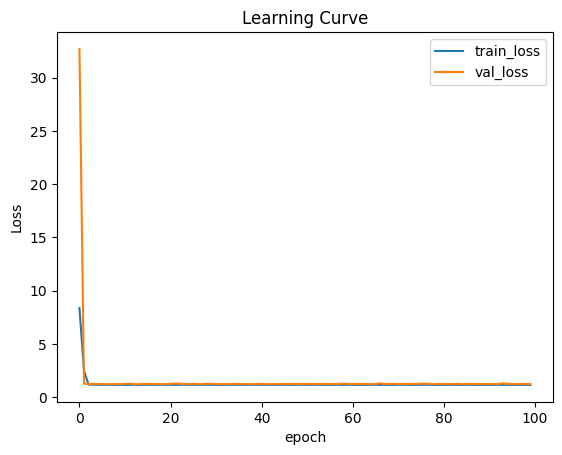

In [109]:
#plt.xlim(0,EPOCHES)
plt.xlabel("epoch")
plt.ylabel("Loss")
#plt.ylim(0,3.0)
plt.plot(np.mean(hist_trn_mse,axis=0), label='train_loss')
plt.plot(np.mean(hist_val_mse,axis=0),label='val_loss')
plt.title("Learning Curve")
plt.legend()
plt.show()

In [99]:
#Prepare test dataset for evaluation
x_test = scaler.transform(x_test.values)

x_test = torch.tensor(x_test,dtype=torch.float32)
y_test = torch.tensor(y_test.to_numpy(),dtype=torch.float32)

In [119]:
y_preds = []
test_dataset = TensorDataset(x_test,y_test)
test_loader = DataLoader(test_dataset,batch_size=1,shuffle=False,pin_memory=True)

model.eval()
with torch.no_grad():
    for data, target in test_loader:
        data,target = data.to(device),target.to(device)
        tst_pred = model(data)
        y_preds.append(tst_pred.item())
        

In [101]:

#pd.DataFrame(y_tst_metric)

In [ ]:
x_metric_dataset.reset_index() 
x_metric_dataset["Finish_Time"] = y_preds

In [103]:
#Checks if loswest finish_time matches won(1) label based on race_id
def predict_winner(group):
    predicted_winner_index = group['Finish_Time'].idxmin()
    return group.loc[predicted_winner_index, 'won'] == 1

results = x_metric_dataset.groupby('race_id').apply(predict_winner)

accuracy = results.mean()
print(f"Prediction Accuracy: {accuracy:.4f} ({results.sum()} correct out of {len(results)} races)")

Prediction Accuracy: 0.1369 (633 correct out of 4623 races)


C:\Users\alanj\AppData\Local\Temp\ipykernel_18028\4053492148.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = x_metric_dataset.groupby('race_id').apply(predict_winner)


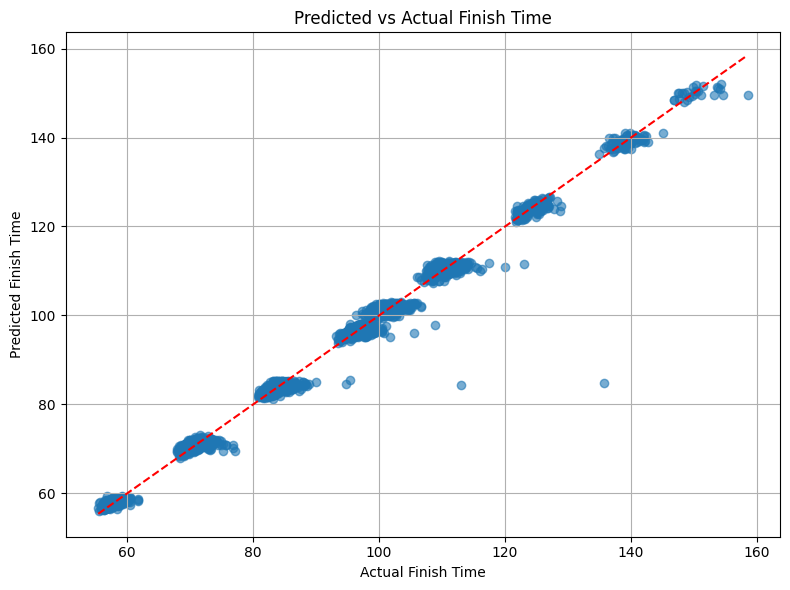

In [120]:
plot_predicted_vs_actual(y_tst_metric,y_preds)